# 11 - Temporal Distribution Shift & Other EDA

A major roadblock in testing the model on data that is temporally different from training is distribution shift. We might expect that as times and culture change, topics and styles might as well. This can make it difficult for models to generalize to timepoints outside of the training range. 

#### 1. We can ask if there are different properties of headlines from around key events in the training time range compared to the rest. 

We do this by taking a 2-week span around a handful of political events and comparing headlines from those windows to all others. We will assess features similar to what has already been done for the dataset in general, namely, headline length, style features, and BERTopic-derived common themes. 

We find that some events are associated with important differences in features, such as a depletion of punctuation and elongation of headlines from FOX around Jan 6 while NBC shows greater single-quote usage around this time. 

#### 2. After removing these key event-tied timepoints, we can assess background temporal trends. 

We visualize with LOESS regression and test significant trends in topics and style features using Spearman correlation. 

We find substantial distribution shift in topics including an increase in crime/immigration and Trump legal issues from FOX, Russia/Ukraine/China from NBC. Interestingly, more of the significant topic shifts are from FOX than NBC suggesting that distribution shift differs both over time and between sources, complicating the classification task further. 

#### 3. Exploring topic modeling

Our embedding-based models performed at higher accuracy than those derived from TF-IDF directly. We ask if this is related to how models pick up on topics/themes. Accordingly we perform Latent Dirichlet Allocation after TF-IDF and compare the resulting themes to the embedding-based BERTopic results. While some themes show clear overlap, like Israel-Gaza and the NBC Select product articles, most themes do not match significantly. 

#### 4. Clustering with embeddings

A remaining question is if there are patterns/separations in our dataset that we can pick up from the embedding. 

A few basic clustering algorithms and PCA for visualization show that FOX and NBC don't obviously separate using unsupervised learning, but instead, there's a large subset of NBC-predominant Israel-Gaza-related articles that cluster distinctly from the rest of the dataset. 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bertopic import BERTopic
from hdbscan import HDBSCAN
from umap import UMAP

from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import spearmanr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

FOX_COLOR = '#E81B23'
NBC_COLOR = '#2A5EAC'
FOX_COLOR_LIGHT = '#F4A9B0'
NBC_COLOR_LIGHT = '#8BB0E8'
ALPHA = 0.75

WINDOW_DAYS = 14
EVENTS = {
    '2020 Election': pd.Timestamp('2020-11-03', tz='UTC'),
    'Jan 6': pd.Timestamp('2021-01-06', tz='UTC'),
    'Midterms': pd.Timestamp('2022-11-08', tz='UTC'),
    '2024 Election': pd.Timestamp('2024-11-05', tz='UTC'),
}

STYLE_COLS = {
    'has_single_quotes': "Single quotes ('word')",
    'has_question': 'Ends with ?',
    'has_colon': 'Contains colon (:)',
    'has_allcaps': 'ALL CAPS word',
}

Loaded 3,805 rows
Rows with titles: 3,801
Rows with titles and datetimes: 3,711
Date range: 2020-01-06 to 2026-04-07
Events: 2020 Election, Jan 6, Midterms, 2024 Election


In [ ]:
df = pd.read_csv('../data/processed/combined_base_data.csv')
df['datetime_posted'] = pd.to_datetime(df['datetime_posted'], format='mixed', utc=True)
df['date'] = df['datetime_posted'].dt.date
df['hour'] = df['datetime_posted'].dt.hour
df['dow'] = df['datetime_posted'].dt.day_name()

topic_df = df.dropna(subset=['title']).copy()
embeddings = np.load('../data/processed/minilm_embeddings.npy')
assert len(embeddings) == len(topic_df), f'Expected {len(topic_df)} embeddings, found {len(embeddings)}'

print(f'Loaded {len(df)} rows')
print(f'Rows with titles: {len(topic_df)}')
print(f'Rows with titles and datetimes: {df.dropna(subset=["title", "datetime_posted"]).shape[0]}')
print(f'Date range: {df["datetime_posted"].min().date()} to {df["datetime_posted"].max().date()}')

Loaded 3,805 rows
Rows with titles: 3,801
Rows with titles and datetimes: 3711
Date range: 2020-01-06 to 2026-04-07


In [ ]:
headline_df = df.dropna(subset=['title', 'datetime_posted']).copy()
headline_df['word_count'] = headline_df['title'].str.split().str.len()
headline_df['char_count'] = headline_df['title'].str.len()
headline_df['has_single_quotes'] = headline_df['title'].str.contains(r"'[^']{1,40}'", regex=True)
headline_df['has_question'] = headline_df['title'].str.endswith('?')
headline_df['has_colon'] = headline_df['title'].str.contains(':', regex=False)
headline_df['has_allcaps'] = headline_df['title'].str.contains(r'\b[A-Z]{3,}\b', regex=True)
headline_df['starts_with_number'] = headline_df['title'].str.match(r'^\d')
headline_df['allcaps_word_count'] = headline_df['title'].str.findall(r'\b[A-Z]{3,}\b').str.len()

print(f'Headline rows available for temporal analysis: {len(headline_df)}')
print(headline_df[['title', 'datetime_posted']].head().to_string())

Headline rows available for temporal analysis: 3,711
                                                                                                         title           datetime_posted
0  Blinken meets Qatar PM, says Israeli actions are not 'retaliation,' but 'defending the lives of its people' 2023-10-13 18:06:08+00:00
1                           Bruce Willis, Demi Moore avoided doing one thing while co-parenting, daughter says 2024-10-18 19:56:05+00:00
2            'The View' co-host, CNN commentator Ana Navarro to host night 2 of Democratic National Convention 2024-08-20 01:00:35+00:00
3  Emily Blunt says her ‘toes curl’ when people tell her their kids want to act: 'I want to say, don’t do it!' 2023-06-09 17:55:28+00:00
4                           Jack Carr recalls Gen. Eisenhower's D-Day memo about 'great and noble undertaking' 2024-06-06 08:30:24+00:00


In [51]:
topic_df = df.dropna(subset=['title']).copy()
headlines = topic_df['title'].tolist()

umap_model = UMAP(n_components=5, random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=30, prediction_data=True)
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics='auto',
    verbose=False,
)

topics, probs = topic_model.fit_transform(headlines, embeddings)

topic_labels = {
    -1: 'Outlier',
     0: 'US Politics / Election',
     1: 'Israel-Gaza Conflict',
     2: 'NBC Select (Product Reviews)',
     3: 'Trump Legal / Jan 6 / Assassination Attempt',
     4: 'Entertainment / Celebrity News',
     5: 'Russia / Ukraine / China',
     6: 'Crime / Immigration',
     7: 'Fox: History Series',
     8: 'Abortion / Reproductive Rights',
     9: 'Fox: Transgender Sports',
    10: 'Hurricanes / Weather',
    11: 'Fox: Health Studies',
    12: 'Fox: Biden Climate Policy',
}

topic_df['topic_id'] = topics
topic_df['topic_label'] = topic_df['topic_id'].map(topic_labels)

print(f'Topics assigned to topic_df: {topic_df.shape}')
print(f'Topic label coverage: {topic_df["topic_label"].notna().sum()}/{len(topic_df)}')

# Merge topics into headline_df
headline_df = headline_df.merge(topic_df[['url', 'topic_id', 'topic_label']], on='url', how='left')
print(f'Topics in headline_df: {headline_df["topic_label"].notna().sum()}')
print(topic_model.get_topic_info()[['Topic', 'Count', 'Name']].head(15).to_string())

Topics assigned to topic_df: (3801, 12)
Topic label coverage: 3801/3801
Topics in headline_df: 3711
    Topic  Count                               Name
0      -1    905                    -1_to_in_the_of
1       0    755        0_harris_trump_kamala_biden
2       1    569        1_israel_gaza_hamas_israeli
3       2    364       2_best_2026_select_according
4       3    335  3_jan_trump_assassination_capitol
5       4    154        4_taylor_willis_swift_bruce
6       5    134         5_russia_korea_north_putin
7       6    128       6_murder_gang_school_illegal
8       7    125              7_day_history_this_in
9       8     92       8_abortion_rights_ballot_ban
10      9     78  9_womens_transgender_sports_title
11     10     69   10_hurricane_helene_milton_storm
12     11     48     11_admin_biden_farmers_climate
13     12     45     12_disease_study_rare_syndrome


# 1. Key Events

In [ ]:
def build_window_mask(frame, event_date, days=WINDOW_DAYS):
    start = event_date - pd.Timedelta(days=days)
    end = event_date + pd.Timedelta(days=days)
    return frame['datetime_posted'].between(start, end)


def compare_event(event_name, event_date):
    window_mask = build_window_mask(headline_df, event_date)
    window_df = headline_df[window_mask].copy()
    baseline_df = headline_df[~window_mask].copy()

    fox_window = window_df[window_df['is_fox'] == 1]
    fox_baseline = baseline_df[baseline_df['is_fox'] == 1]
    nbc_window = window_df[window_df['is_fox'] == 0]
    nbc_baseline = baseline_df[baseline_df['is_fox'] == 0]

    print(f'{event_name}')
    print(f'Fox window: {len(fox_window)} | Fox baseline: {len(fox_baseline)}')
    print(f'NBC window: {len(nbc_window)} | NBC baseline: {len(nbc_baseline)}')

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f'{event_name} vs baseline: Fox (top) vs NBC (bottom)', fontweight='bold', fontsize=14)

    source_configs = [
        (fox_window, fox_baseline, FOX_COLOR, FOX_COLOR_LIGHT),
        (nbc_window, nbc_baseline, NBC_COLOR, NBC_COLOR_LIGHT),
    ]

    for row, (data_window, data_baseline, color_win, color_base) in enumerate(source_configs):
        ax = axes[row, 0]
        max_words = max(data_window['word_count'].max(), data_baseline['word_count'].max())
        bins = range(0, int(max_words) + 3, 2)
        ax.hist(data_baseline['word_count'], bins=bins, color=color_base, alpha=0.6, density=True, label='Baseline')
        ax.hist(data_window['word_count'], bins=bins, color=color_win, alpha=0.75, density=True, label='Window')
        ax.axvline(data_window['word_count'].median(), color=color_win, linestyle='--', linewidth=1.5, alpha=0.9)
        ax.axvline(data_baseline['word_count'].median(), color=color_base, linestyle='--', linewidth=1.5, alpha=0.7)
        ax.set_title('Headline Length: Words' if row == 0 else '', fontweight='bold', fontsize=11)
        ax.set_ylabel('Density')
        ax.grid(axis='y', alpha=0.3)
        if row == 0:
            ax.legend(fontsize=9, loc='upper right')

        ax = axes[row, 1]
        max_chars = max(data_window['char_count'].max() if len(data_window) > 0 else 0,
                        data_baseline['char_count'].max() if len(data_baseline) > 0 else 0)
        bins = range(0, int(max_chars) + 10, 10)
        ax.hist(data_baseline['char_count'], bins=bins, color=color_base, alpha=0.6, density=True, label='Baseline')
        ax.hist(data_window['char_count'], bins=bins, color=color_win, alpha=0.75, density=True, label='Window')
        ax.axvline(data_window['char_count'].median(), color=color_win, linestyle='--', linewidth=1.5, alpha=0.9)
        ax.axvline(data_baseline['char_count'].median(), color=color_base, linestyle='--', linewidth=1.5, alpha=0.7)
        ax.set_title('Headline Length: Characters' if row == 0 else '', fontweight='bold', fontsize=11)
        ax.set_ylabel('Density')
        ax.grid(axis='y', alpha=0.3)
        if row == 0:
            ax.legend(fontsize=9, loc='upper right')

        ax = axes[row, 2]
        style_rates = pd.DataFrame({
            'Baseline': [data_baseline[c].mean() * 100 if len(data_baseline) > 0 else 0 for c in STYLE_COLS],
            'Window': [data_window[c].mean() * 100 if len(data_window) > 0 else 0 for c in STYLE_COLS],
        }, index=STYLE_COLS.values())
        y = np.arange(len(style_rates))
        width = 0.35
        ax.barh(y - width / 2, style_rates['Baseline'], width, color=color_base, alpha=0.6, label='Baseline')
        ax.barh(y + width / 2, style_rates['Window'], width, color=color_win, alpha=0.8, label='Window')
        ax.set_yticks(y)
        ax.set_yticklabels(style_rates.index, fontsize=9)
        ax.set_title('Style Signals' if row == 0 else '', fontweight='bold', fontsize=11)
        ax.set_xlabel('% of headlines')
        ax.grid(axis='x', alpha=0.3)
        if row == 0:
            ax.legend(fontsize=9)

        ax = axes[row, 3]
        topic_share = pd.DataFrame({
            'Baseline': data_baseline['topic_label'].value_counts(normalize=True) * 100,
            'Window': data_window['topic_label'].value_counts(normalize=True) * 100,
        }).fillna(0)
        topic_share['abs_diff'] = (topic_share['Window'] - topic_share['Baseline']).abs()
        top_topics = topic_share.sort_values('abs_diff', ascending=False).head(8)
        y = np.arange(len(top_topics))
        width = 0.35
        ax.barh(y - width / 2, top_topics['Baseline'], width, color=color_base, alpha=0.6, label='Baseline')
        ax.barh(y + width / 2, top_topics['Window'], width, color=color_win, alpha=0.8, label='Window')
        ax.set_yticks(y)
        ax.set_yticklabels(top_topics.index, fontsize=9)
        ax.set_title('Topic Mix' if row == 0 else '', fontweight='bold', fontsize=11)
        ax.set_xlabel('% of headlines')
        ax.grid(axis='x', alpha=0.3)
        if row == 0:
            ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

2020 Election
Fox window: 1 | Fox baseline: 1999
NBC window: 4 | NBC baseline: 1707


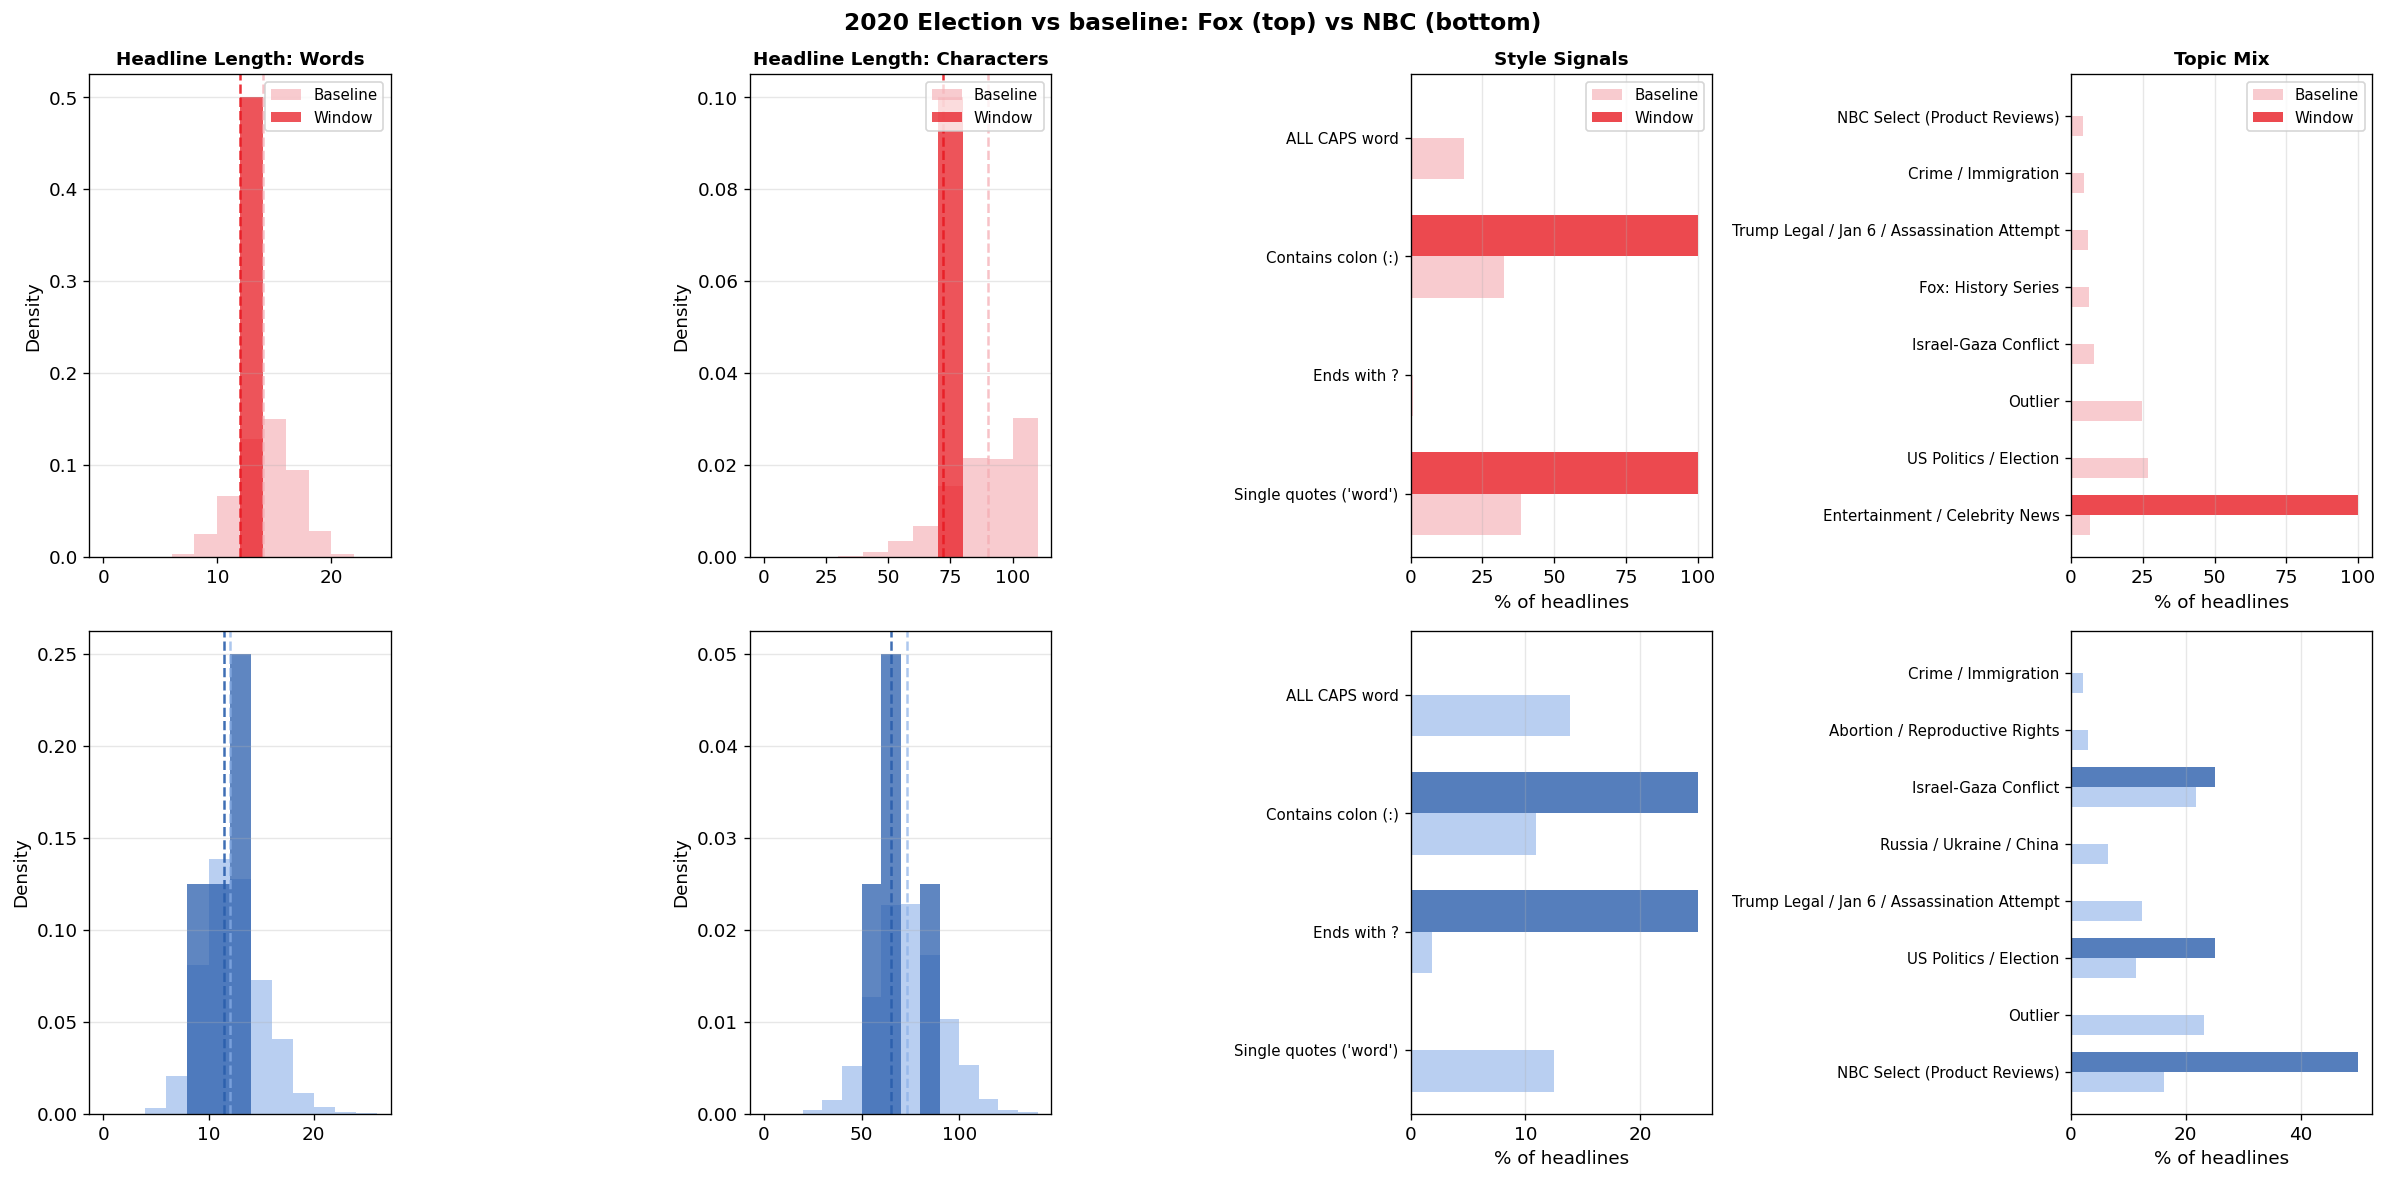

Jan 6
Fox window: 2 | Fox baseline: 1998
NBC window: 8 | NBC baseline: 1703


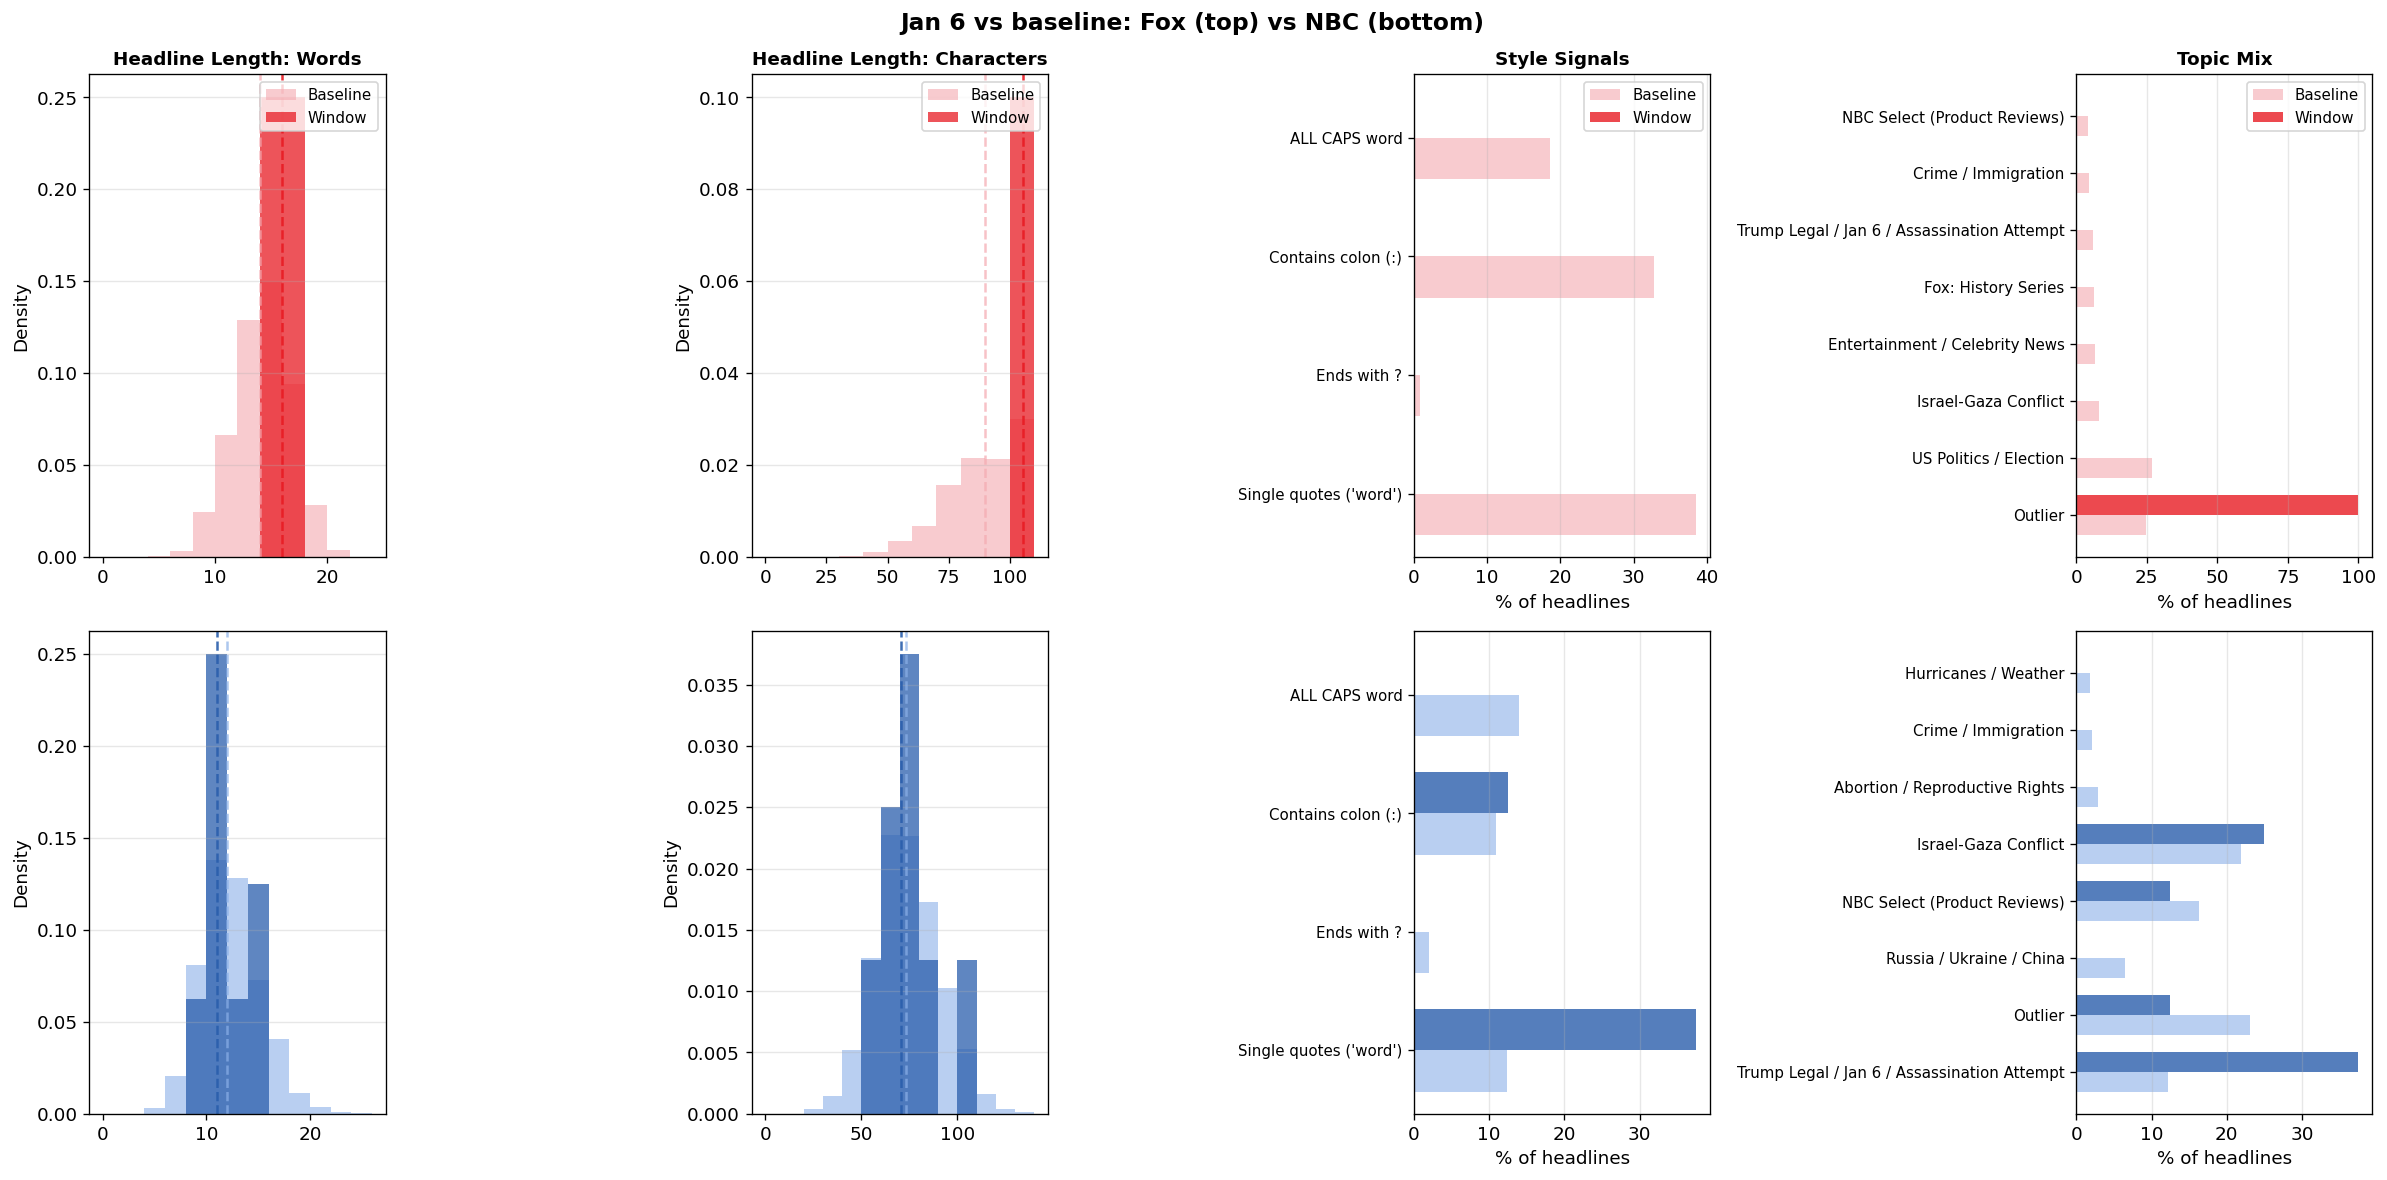

Midterms
Fox window: 19 | Fox baseline: 1981
NBC window: 21 | NBC baseline: 1690


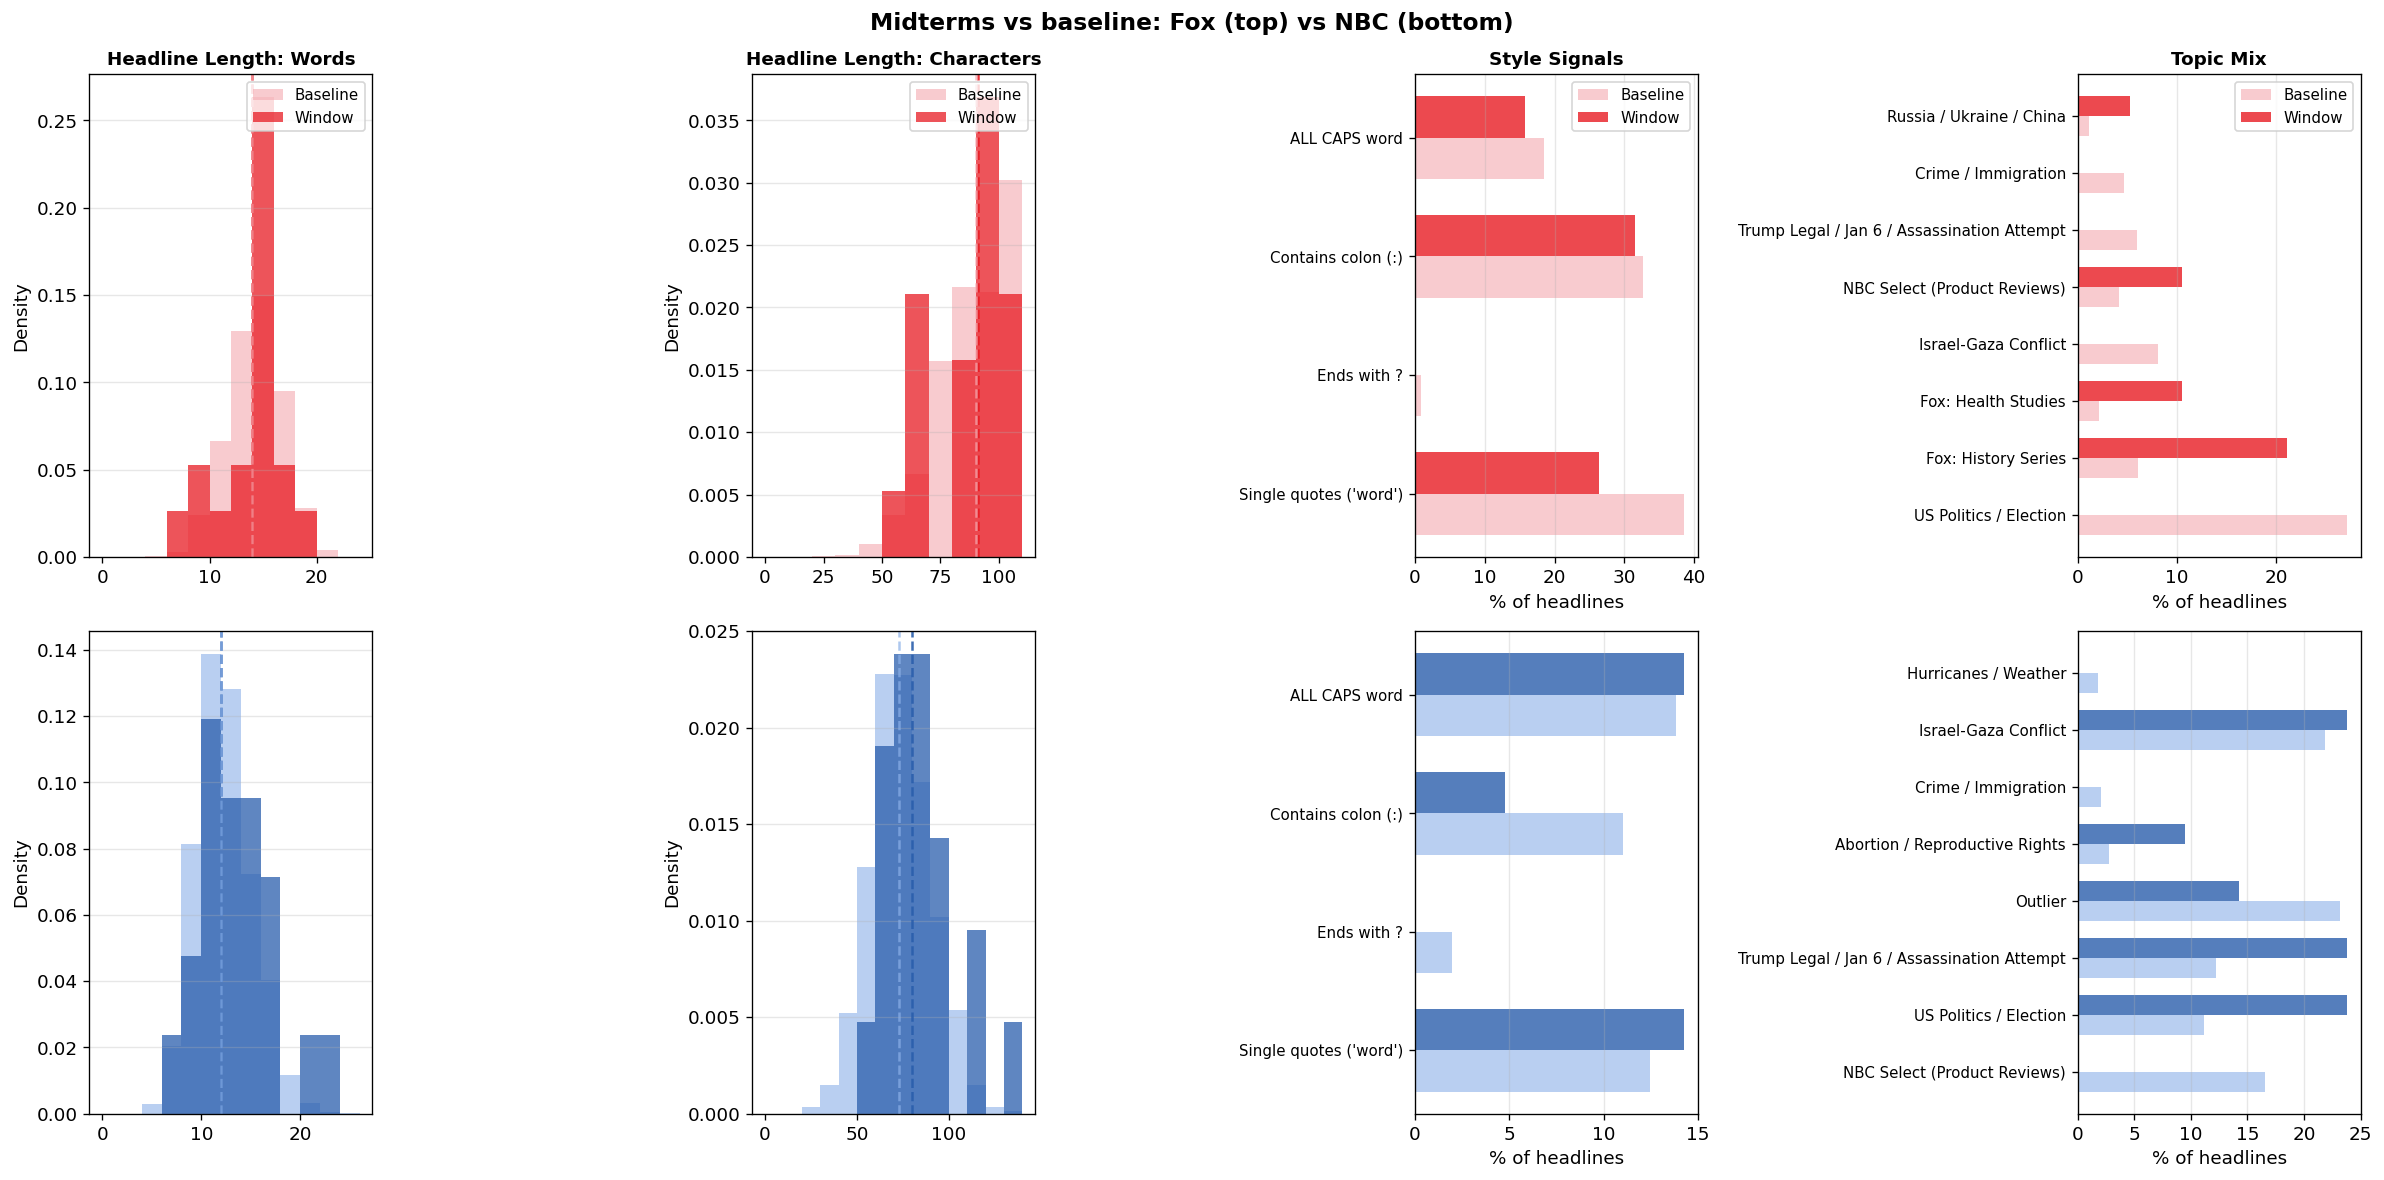

2024 Election
Fox window: 2 | Fox baseline: 1998
NBC window: 6 | NBC baseline: 1705


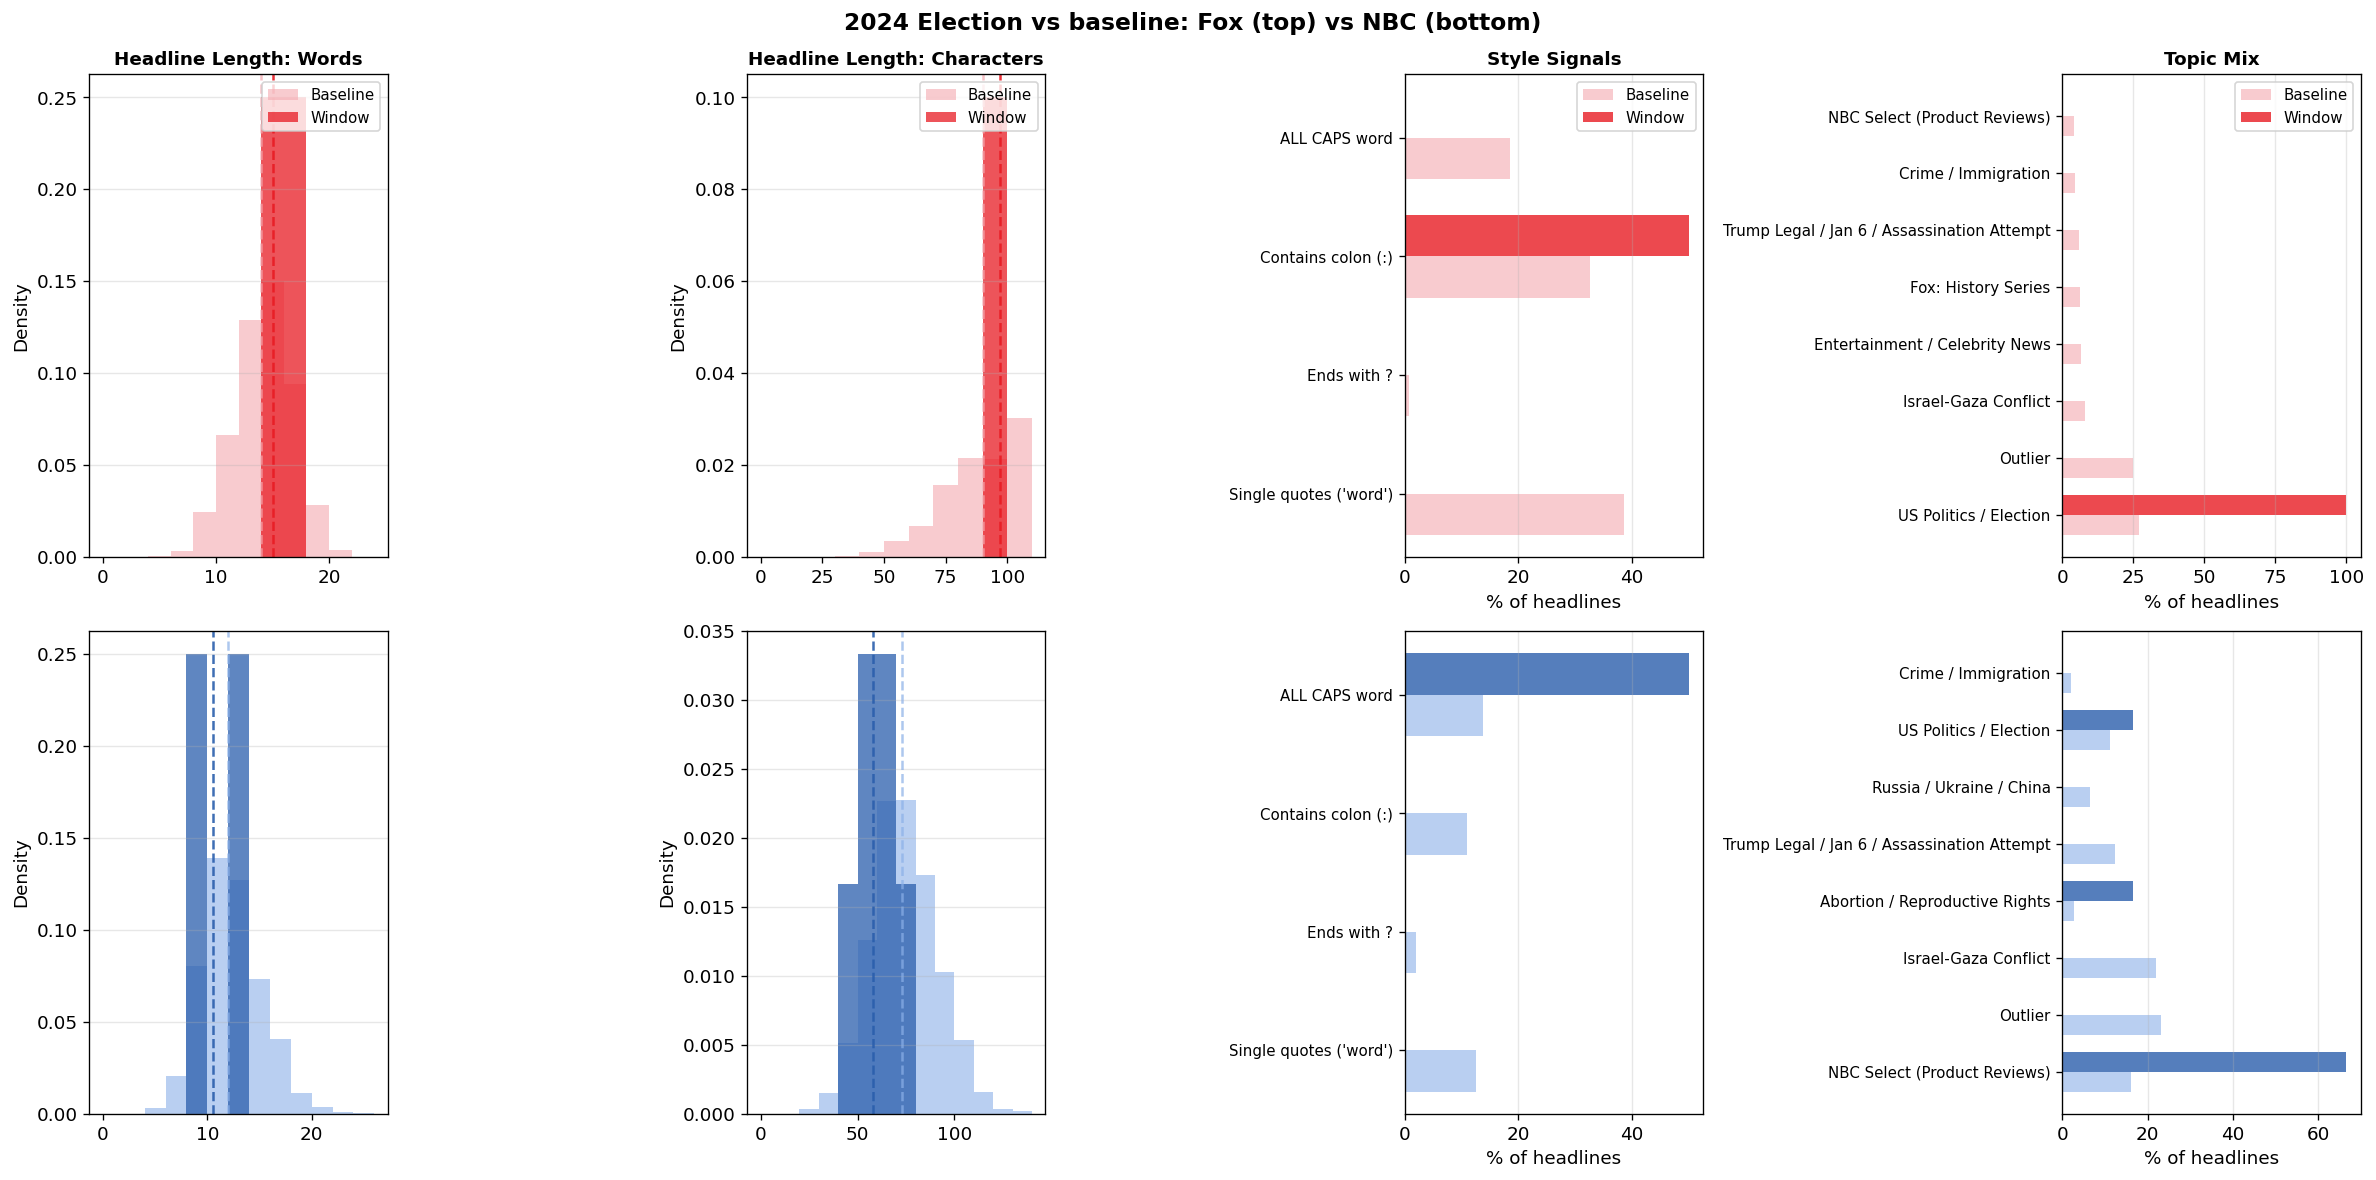

In [53]:
for event_name, event_date in EVENTS.items():
    compare_event(event_name, event_date)

# 2. Background over time

In [55]:
# exclude event windows
all_window_masks = []
for event_name, event_date in EVENTS.items():
    mask = build_window_mask(headline_df, event_date)
    all_window_masks.append(mask)
combined_window_mask = all_window_masks[0]
for mask in all_window_masks[1:]:
    combined_window_mask = combined_window_mask | mask
baseline_df = headline_df[~combined_window_mask].copy()

print(f'Removed {combined_window_mask.sum()} articles in event windows, leaving {len(baseline_df)} baseline articles')
print(f'Fox: {(baseline_df["is_fox"] == 1).sum()}')
print(f'NBC: {(baseline_df["is_fox"] == 0).sum()}')

Removed 63 articles in event windows, leaving 3648 baseline articles
Fox: 1976
NBC: 1672


Fox date range: 2020-01 to 2025-03
NBC date range: 2020-01 to 2026-04
Overlapping range: 2020-01 to 2025-03


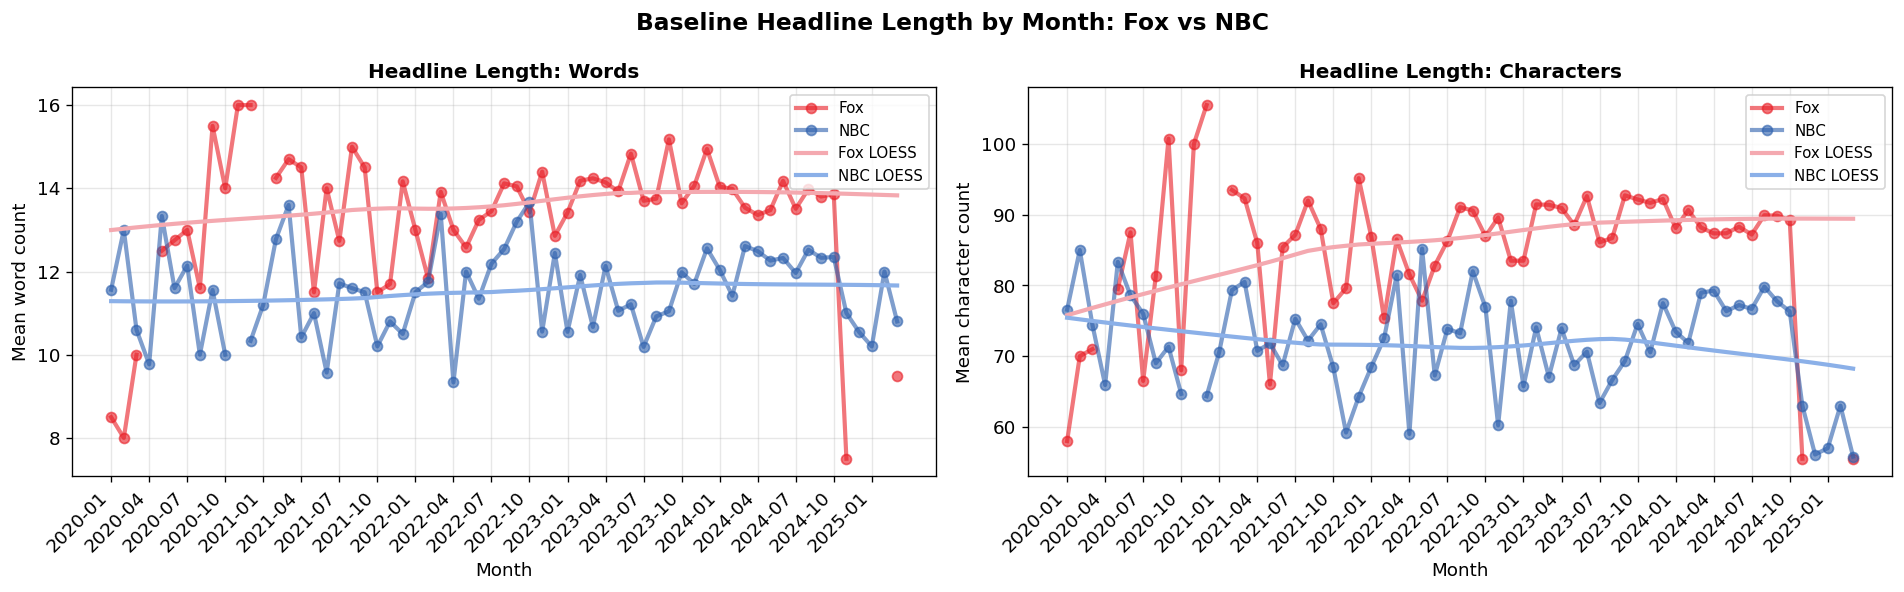

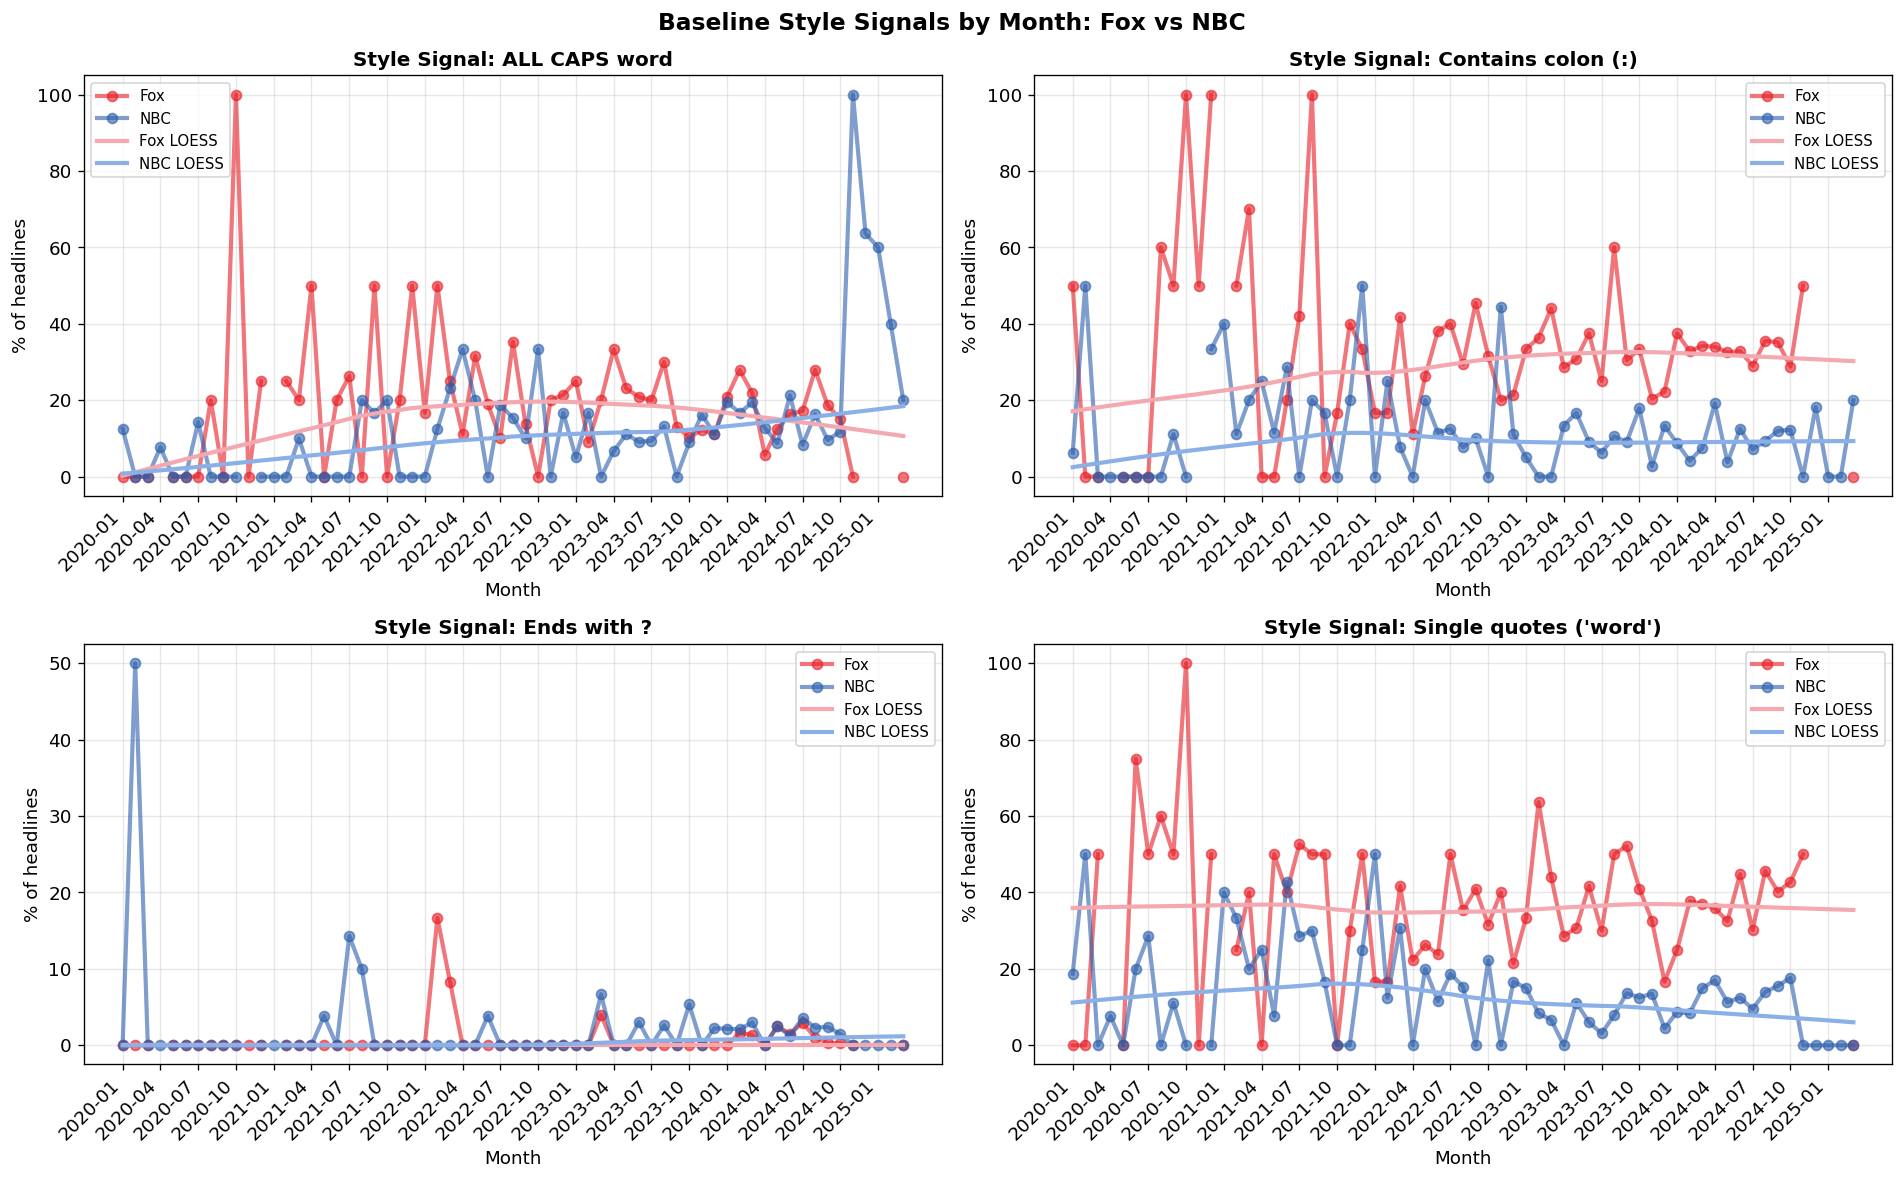

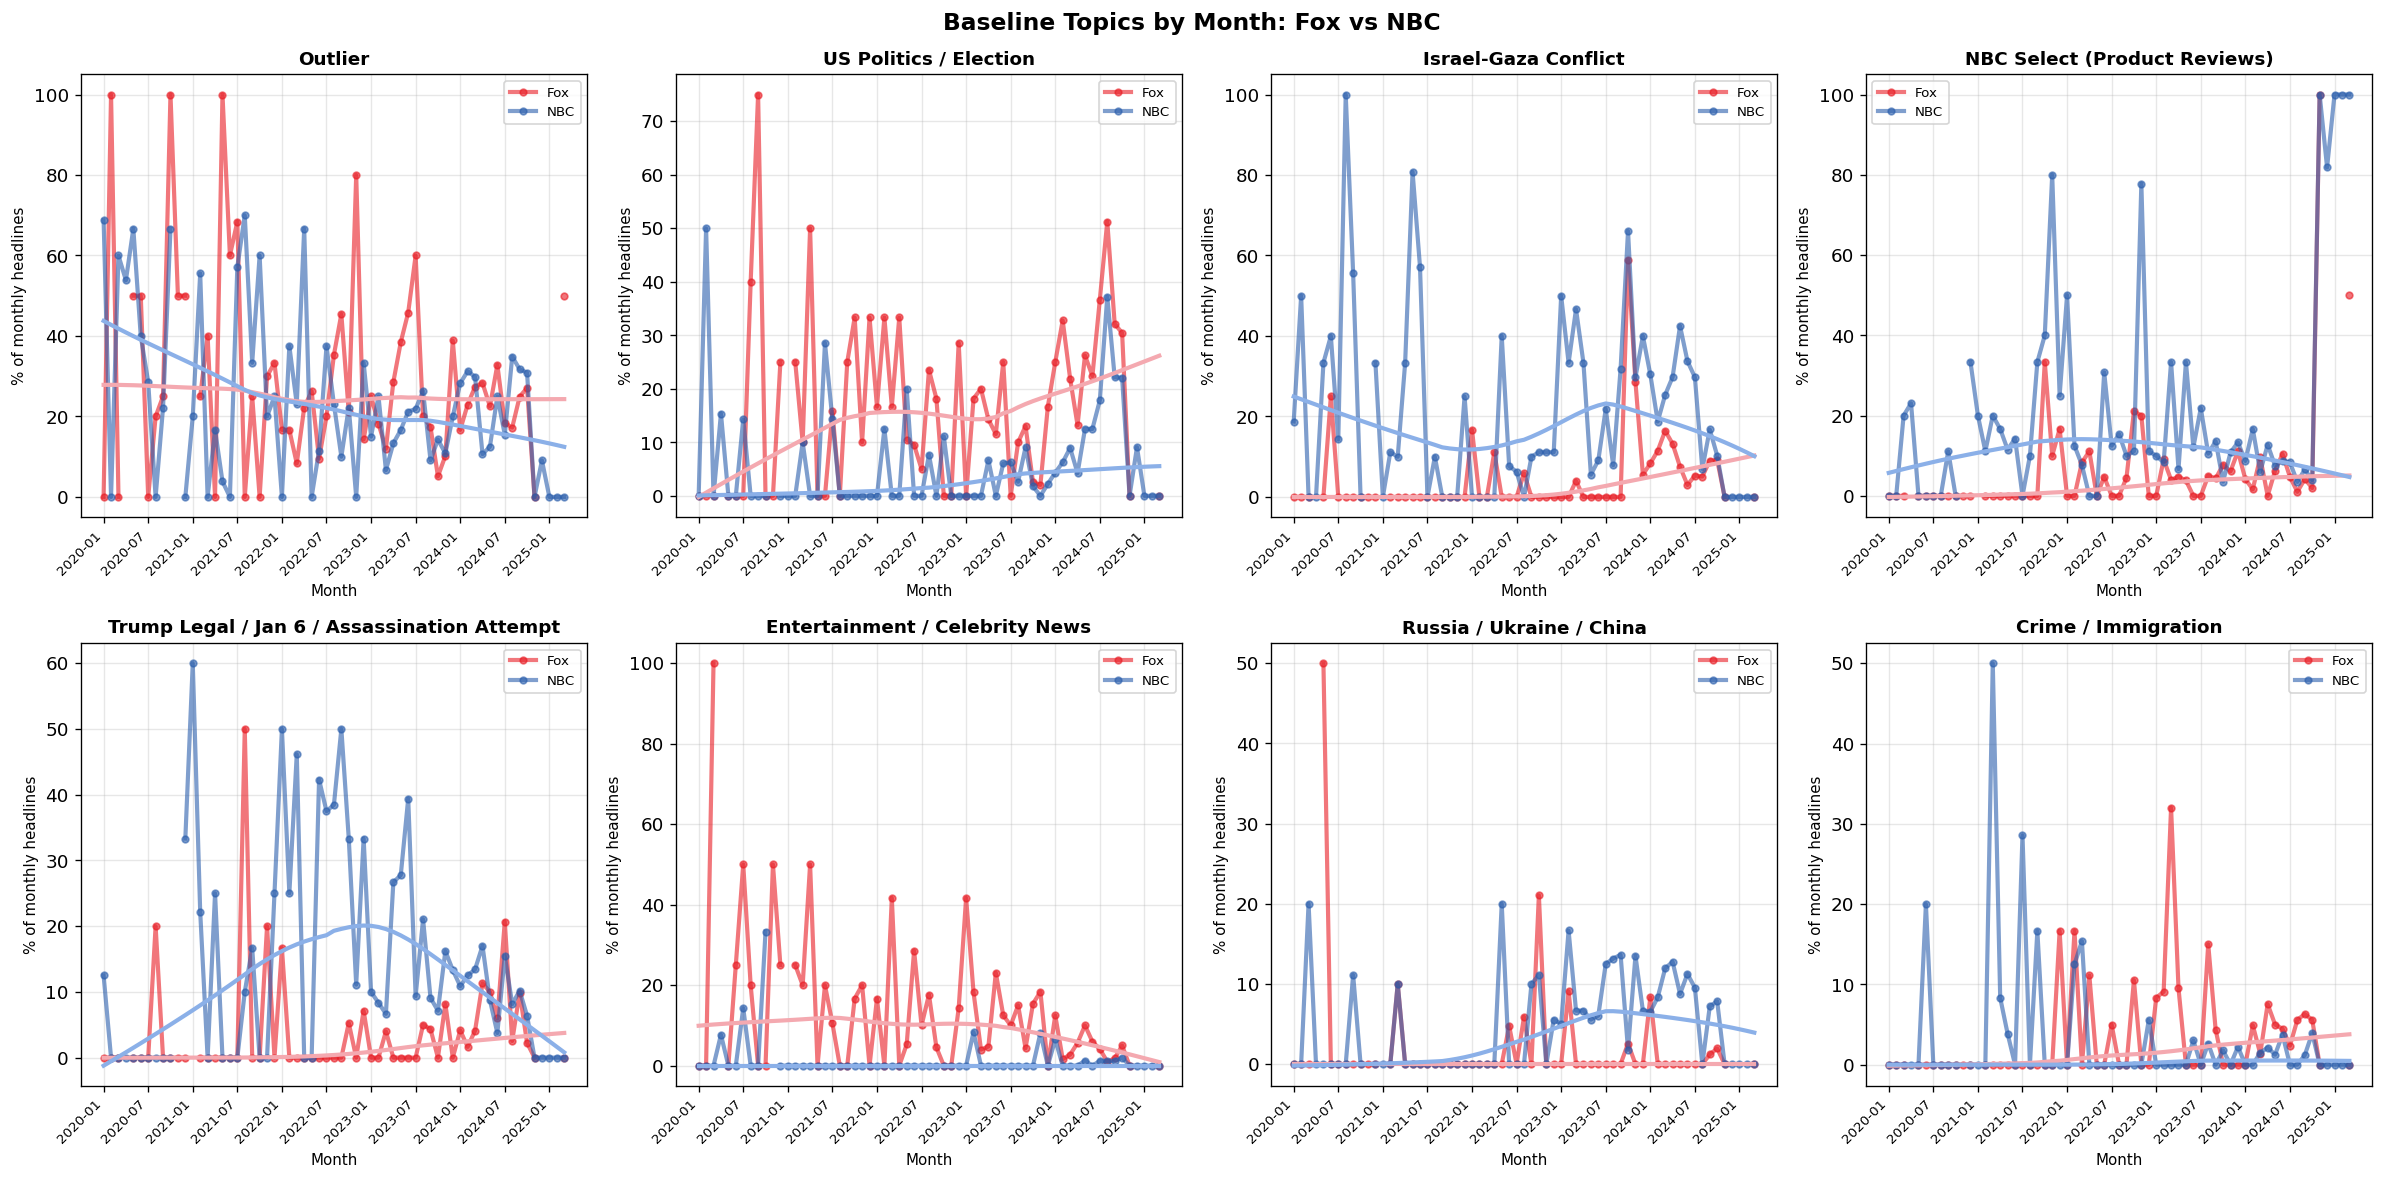

Significant correlations (p < 0.05)
   Dataset                                            Feature       Rho  \
18     All                                     Topic: Outlier -0.202298   
20     NBC                                     Topic: Outlier -0.286338   
21     All                      Topic: US Politics / Election  0.221132   
25     Fox                        Topic: Israel-Gaza Conflict  0.488795   
27     All                Topic: NBC Select (Product Reviews)  0.355473   
28     Fox                Topic: NBC Select (Product Reviews)  0.581613   
30     All  Topic: Trump Legal / Jan 6 / Assassination Att...  0.244615   
31     Fox  Topic: Trump Legal / Jan 6 / Assassination Att...  0.418283   
36     All                    Topic: Russia / Ukraine / China  0.265882   
38     NBC                    Topic: Russia / Ukraine / China  0.369776   
39     All                         Topic: Crime / Immigration  0.242429   
40     Fox                         Topic: Crime / Immigration  0

In [ ]:
# Month binning for viz
baseline_df['year_month'] = baseline_df['datetime_posted'].dt.to_period('M')

monthly_agg = baseline_df.groupby(['year_month', 'is_fox']).agg({
    'word_count': 'mean',
    'char_count': 'mean',
    'has_single_quotes': 'mean',
    'has_question': 'mean',
    'has_colon': 'mean',
    'has_allcaps': 'mean',
}).reset_index()

fox_monthly_orig = monthly_agg[monthly_agg['is_fox'] == 1].set_index('year_month').sort_index()
nbc_monthly_orig = monthly_agg[monthly_agg['is_fox'] == 0].set_index('year_month').sort_index()

fox_min, fox_max = fox_monthly_orig.index.min(), fox_monthly_orig.index.max()
nbc_min, nbc_max = nbc_monthly_orig.index.min(), nbc_monthly_orig.index.max()

overlap_start = max(fox_min, nbc_min)
overlap_end = min(fox_max, nbc_max)

print(f'Fox date range: {fox_min} to {fox_max}')
print(f'NBC date range: {nbc_min} to {nbc_max}')
print(f'Overlapping range: {overlap_start} to {overlap_end}')

# restrict time axis for fair comparison
full_month_range = pd.period_range(start=overlap_start, end=overlap_end, freq='M')

fox_monthly = fox_monthly_orig.reindex(full_month_range)
nbc_monthly = nbc_monthly_orig.reindex(full_month_range)
time_labels = [str(t) for t in full_month_range]
time_x = range(len(time_labels))
time_x_numeric = np.arange(len(time_labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Baseline Headline Length by Month: Fox vs NBC', fontweight='bold', fontsize=14)

ax = axes[0]
fox_wc = fox_monthly['word_count'].values
nbc_wc = nbc_monthly['word_count'].values
ax.plot(time_x, fox_wc, color=FOX_COLOR, label='Fox', linewidth=2.5, marker='o', alpha=0.6)
ax.plot(time_x, nbc_wc, color=NBC_COLOR, label='NBC', linewidth=2.5, marker='o', alpha=0.6)

fox_wc_smooth = lowess(fox_wc, time_x_numeric)
nbc_wc_smooth = lowess(nbc_wc, time_x_numeric)
ax.plot(fox_wc_smooth[:, 0], fox_wc_smooth[:, 1], color=FOX_COLOR_LIGHT, linewidth=2.5, label='Fox LOESS')
ax.plot(nbc_wc_smooth[:, 0], nbc_wc_smooth[:, 1], color=NBC_COLOR_LIGHT, linewidth=2.5, label='NBC LOESS')

ax.set_title('Headline Length: Words', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean word count')
ax.set_xlabel('Month')
ax.set_xticks(time_x[::3])
ax.set_xticklabels(time_labels[::3], rotation=45, ha='right')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
fox_cc = fox_monthly['char_count'].values
nbc_cc = nbc_monthly['char_count'].values
ax.plot(time_x, fox_cc, color=FOX_COLOR, label='Fox', linewidth=2.5, marker='o', alpha=0.6)
ax.plot(time_x, nbc_cc, color=NBC_COLOR, label='NBC', linewidth=2.5, marker='o', alpha=0.6)

fox_cc_smooth = lowess(fox_cc, time_x_numeric)
nbc_cc_smooth = lowess(nbc_cc, time_x_numeric)
ax.plot(fox_cc_smooth[:, 0], fox_cc_smooth[:, 1], color=FOX_COLOR_LIGHT, linewidth=2.5, label='Fox LOESS')
ax.plot(nbc_cc_smooth[:, 0], nbc_cc_smooth[:, 1], color=NBC_COLOR_LIGHT, linewidth=2.5, label='NBC LOESS')

ax.set_title('Headline Length: Characters', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean character count')
ax.set_xlabel('Month')
ax.set_xticks(time_x[::3])
ax.set_xticklabels(time_labels[::3], rotation=45, ha='right')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Baseline Style Signals by Month: Fox vs NBC', fontweight='bold', fontsize=14)

style_order = ['has_allcaps', 'has_colon', 'has_question', 'has_single_quotes']
style_labels = ['ALL CAPS word', 'Contains colon (:)', 'Ends with ?', "Single quotes ('word')"]

for idx, (style_col, style_label) in enumerate(zip(style_order, style_labels)):
    ax = axes[idx // 2, idx % 2]
    fox_style = fox_monthly[style_col].values * 100
    nbc_style = nbc_monthly[style_col].values * 100
    
    ax.plot(time_x, fox_style, color=FOX_COLOR, label='Fox', linewidth=2.5, marker='o', alpha=0.6)
    ax.plot(time_x, nbc_style, color=NBC_COLOR, label='NBC', linewidth=2.5, marker='o', alpha=0.6)
    
    fox_style_smooth = lowess(fox_style, time_x_numeric)
    nbc_style_smooth = lowess(nbc_style, time_x_numeric)
    ax.plot(fox_style_smooth[:, 0], fox_style_smooth[:, 1], color=FOX_COLOR_LIGHT, linewidth=2.5, label='Fox LOESS')
    ax.plot(nbc_style_smooth[:, 0], nbc_style_smooth[:, 1], color=NBC_COLOR_LIGHT, linewidth=2.5, label='NBC LOESS')
    
    ax.set_title(f'Style Signal: {style_label}', fontweight='bold', fontsize=12)
    ax.set_ylabel('% of headlines')
    ax.set_xlabel('Month')
    ax.set_xticks(time_x[::3])
    ax.set_xticklabels(time_labels[::3], rotation=45, ha='right')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

top_topics = baseline_df['topic_label'].value_counts().head(8).index.tolist()

topic_monthly = baseline_df.groupby(['year_month', 'is_fox', 'topic_label']).size().unstack(fill_value=0)
topic_monthly_pct = topic_monthly.div(topic_monthly.sum(axis=1), axis=0) * 100

# grid for topic trends
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Baseline Topics by Month: Fox vs NBC', fontweight='bold', fontsize=14)

for idx, topic in enumerate(top_topics):
    ax = axes[idx // 4, idx % 4]
    
    fox_topic_pcts = []
    nbc_topic_pcts = []
    
    for month in full_month_range:
        fox_idx = (month, 1)
        nbc_idx = (month, 0)
        
        if fox_idx in topic_monthly_pct.index and topic in topic_monthly_pct.columns:
            fox_topic_pcts.append(topic_monthly_pct.loc[fox_idx, topic])
        else:
            fox_topic_pcts.append(np.nan)
        
        if nbc_idx in topic_monthly_pct.index and topic in topic_monthly_pct.columns:
            nbc_topic_pcts.append(topic_monthly_pct.loc[nbc_idx, topic])
        else:
            nbc_topic_pcts.append(np.nan)
    
    fox_topic_pcts = np.array(fox_topic_pcts)
    nbc_topic_pcts = np.array(nbc_topic_pcts)
    
    ax.plot(time_x, fox_topic_pcts, color=FOX_COLOR, label='Fox', linewidth=2.5, marker='o', markersize=4, alpha=0.6)
    ax.plot(time_x, nbc_topic_pcts, color=NBC_COLOR, label='NBC', linewidth=2.5, marker='o', markersize=4, alpha=0.6)
    
    # Add LOESS smooth lines (handle NaN values)
    fox_valid = ~np.isnan(fox_topic_pcts)
    nbc_valid = ~np.isnan(nbc_topic_pcts)
    if fox_valid.sum() > 3:
        fox_topic_smooth = lowess(fox_topic_pcts[fox_valid], time_x_numeric[fox_valid])
        ax.plot(fox_topic_smooth[:, 0], fox_topic_smooth[:, 1], color=FOX_COLOR_LIGHT, linewidth=2.5)
    if nbc_valid.sum() > 3:
        nbc_topic_smooth = lowess(nbc_topic_pcts[nbc_valid], time_x_numeric[nbc_valid])
        ax.plot(nbc_topic_smooth[:, 0], nbc_topic_smooth[:, 1], color=NBC_COLOR_LIGHT, linewidth=2.5)
    
    ax.set_title(topic, fontweight='bold', fontsize=11)
    ax.set_ylabel('% of monthly headlines', fontsize=9)
    ax.set_xlabel('Month', fontsize=9)
    ax.set_xticks(time_x[::6])
    ax.set_xticklabels(time_labels[::6], rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# cor testing
corr_results = []

metrics_to_test = [
    ('word_count', 'Headline Length: Words'),
    ('char_count', 'Headline Length: Characters'),
    ('has_allcaps', 'Style: ALL CAPS word'),
    ('has_colon', 'Style: Contains colon (:)'),
    ('has_question', 'Style: Ends with ?'),
    ('has_single_quotes', "Style: Single quotes ('word')"),
]

for topic in top_topics:
    metrics_to_test.append((topic, f'Topic: {topic}'))

for metric_col, metric_label in metrics_to_test:
    if metric_col in ['word_count', 'char_count', 'has_allcaps', 'has_colon', 'has_question', 'has_single_quotes']:
        fox_vals = fox_monthly[metric_col].values
        if metric_col in ['has_allcaps', 'has_colon', 'has_question', 'has_single_quotes']:
            fox_vals = fox_vals * 100
        nbc_vals = nbc_monthly[metric_col].values
        if metric_col in ['has_allcaps', 'has_colon', 'has_question', 'has_single_quotes']:
            nbc_vals = nbc_vals * 100
        
        all_vals = np.concatenate([fox_vals, nbc_vals])
        all_time = np.concatenate([time_x_numeric, time_x_numeric])
        rho_all, pval_all = spearmanr(all_time, all_vals)
        
        rho_fox, pval_fox = spearmanr(time_x_numeric, fox_vals)
        
        rho_nbc, pval_nbc = spearmanr(time_x_numeric, nbc_vals)
        
        corr_results.append(('All', metric_label, rho_all, pval_all))
        corr_results.append(('Fox', metric_label, rho_fox, pval_fox))
        corr_results.append(('NBC', metric_label, rho_nbc, pval_nbc))
    
    else:
        fox_topic_pcts = []
        nbc_topic_pcts = []
        
        for month in full_month_range:
            fox_idx = (month, 1)
            nbc_idx = (month, 0)
            
            if fox_idx in topic_monthly_pct.index and metric_col in topic_monthly_pct.columns:
                fox_topic_pcts.append(topic_monthly_pct.loc[fox_idx, metric_col])
            else:
                fox_topic_pcts.append(np.nan)
            
            if nbc_idx in topic_monthly_pct.index and metric_col in topic_monthly_pct.columns:
                nbc_topic_pcts.append(topic_monthly_pct.loc[nbc_idx, metric_col])
            else:
                nbc_topic_pcts.append(np.nan)
        
        fox_topic_pcts = np.array(fox_topic_pcts)
        nbc_topic_pcts = np.array(nbc_topic_pcts)
        
        all_topic_vals = np.concatenate([fox_topic_pcts, nbc_topic_pcts])
        all_topic_time = np.concatenate([time_x_numeric, time_x_numeric])
        valid_idx = ~np.isnan(all_topic_vals)
        rho_all, pval_all = spearmanr(all_topic_time[valid_idx], all_topic_vals[valid_idx])
        
        valid_fox = ~np.isnan(fox_topic_pcts)
        if valid_fox.sum() > 0:
            rho_fox, pval_fox = spearmanr(time_x_numeric[valid_fox], fox_topic_pcts[valid_fox])
        else:
            rho_fox, pval_fox = np.nan, np.nan
        
        valid_nbc = ~np.isnan(nbc_topic_pcts)
        if valid_nbc.sum() > 0:
            rho_nbc, pval_nbc = spearmanr(time_x_numeric[valid_nbc], nbc_topic_pcts[valid_nbc])
        else:
            rho_nbc, pval_nbc = np.nan, np.nan
        
        corr_results.append(('All', metric_label, rho_all, pval_all))
        corr_results.append(('Fox', metric_label, rho_fox, pval_fox))
        corr_results.append(('NBC', metric_label, rho_nbc, pval_nbc))

corr_df = pd.DataFrame(corr_results, columns=['Dataset', 'Feature', 'Rho', 'P-Value'])
print('Significant correlations (p < 0.05)')
sig_results = corr_df[corr_df['P-Value'].astype(float) < 0.05].copy()
print(sig_results)

# 3. BERTopic vs TF-IDF -> LDA

In [ ]:

vectorizer = TfidfVectorizer(ngram_range=(1, 4), max_features=1000, min_df=2, max_df=0.98, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(headlines)

lda_model = LatentDirichletAllocation(n_components=13, random_state=42)
lda_topic_probs = lda_model.fit_transform(tfidf_matrix)
lda_assignments = lda_topic_probs.argmax(axis=1)

lda_info = get_lda_topic_info(lda_model, vectorizer, lda_assignments)
feature_names = vectorizer.get_feature_names_out()
topics_list = []
for topic_id in range(13):
    top_words_idx = lda_model.components_[topic_id].argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    name = ' + '.join(top_words[:5])
    topics_list.append({
        'Topic': topic_id,
        'Name': name,
    })
lda_info = pd.DataFrame(topics_list)
print(lda_info.to_string(index=False))

 Topic                                                 Name
     0           best + according + 2026 + experts + select
     1                house + white + harris + time + media
     2          attacks + family + running + america + face
     3             day + history + fox + news + day history
     4               case + trump + judge + year + election
     5            trump + harris + biden + voters + reveals
     6        florida + rights + abortion + pro + hurricane
     7          campaign + government + trump + biden + new
     8       debate + taylor + trump + swift + taylor swift
     9               jan + trump + anti + prison + congress
    10 assassination + secret + service + attempt + illegal
    11 kamala + kamala harris + harris + democratic + covid
    12           israel + hamas + gaza + israeli + american


Comparing 3711 articles (those with title AND datetime)


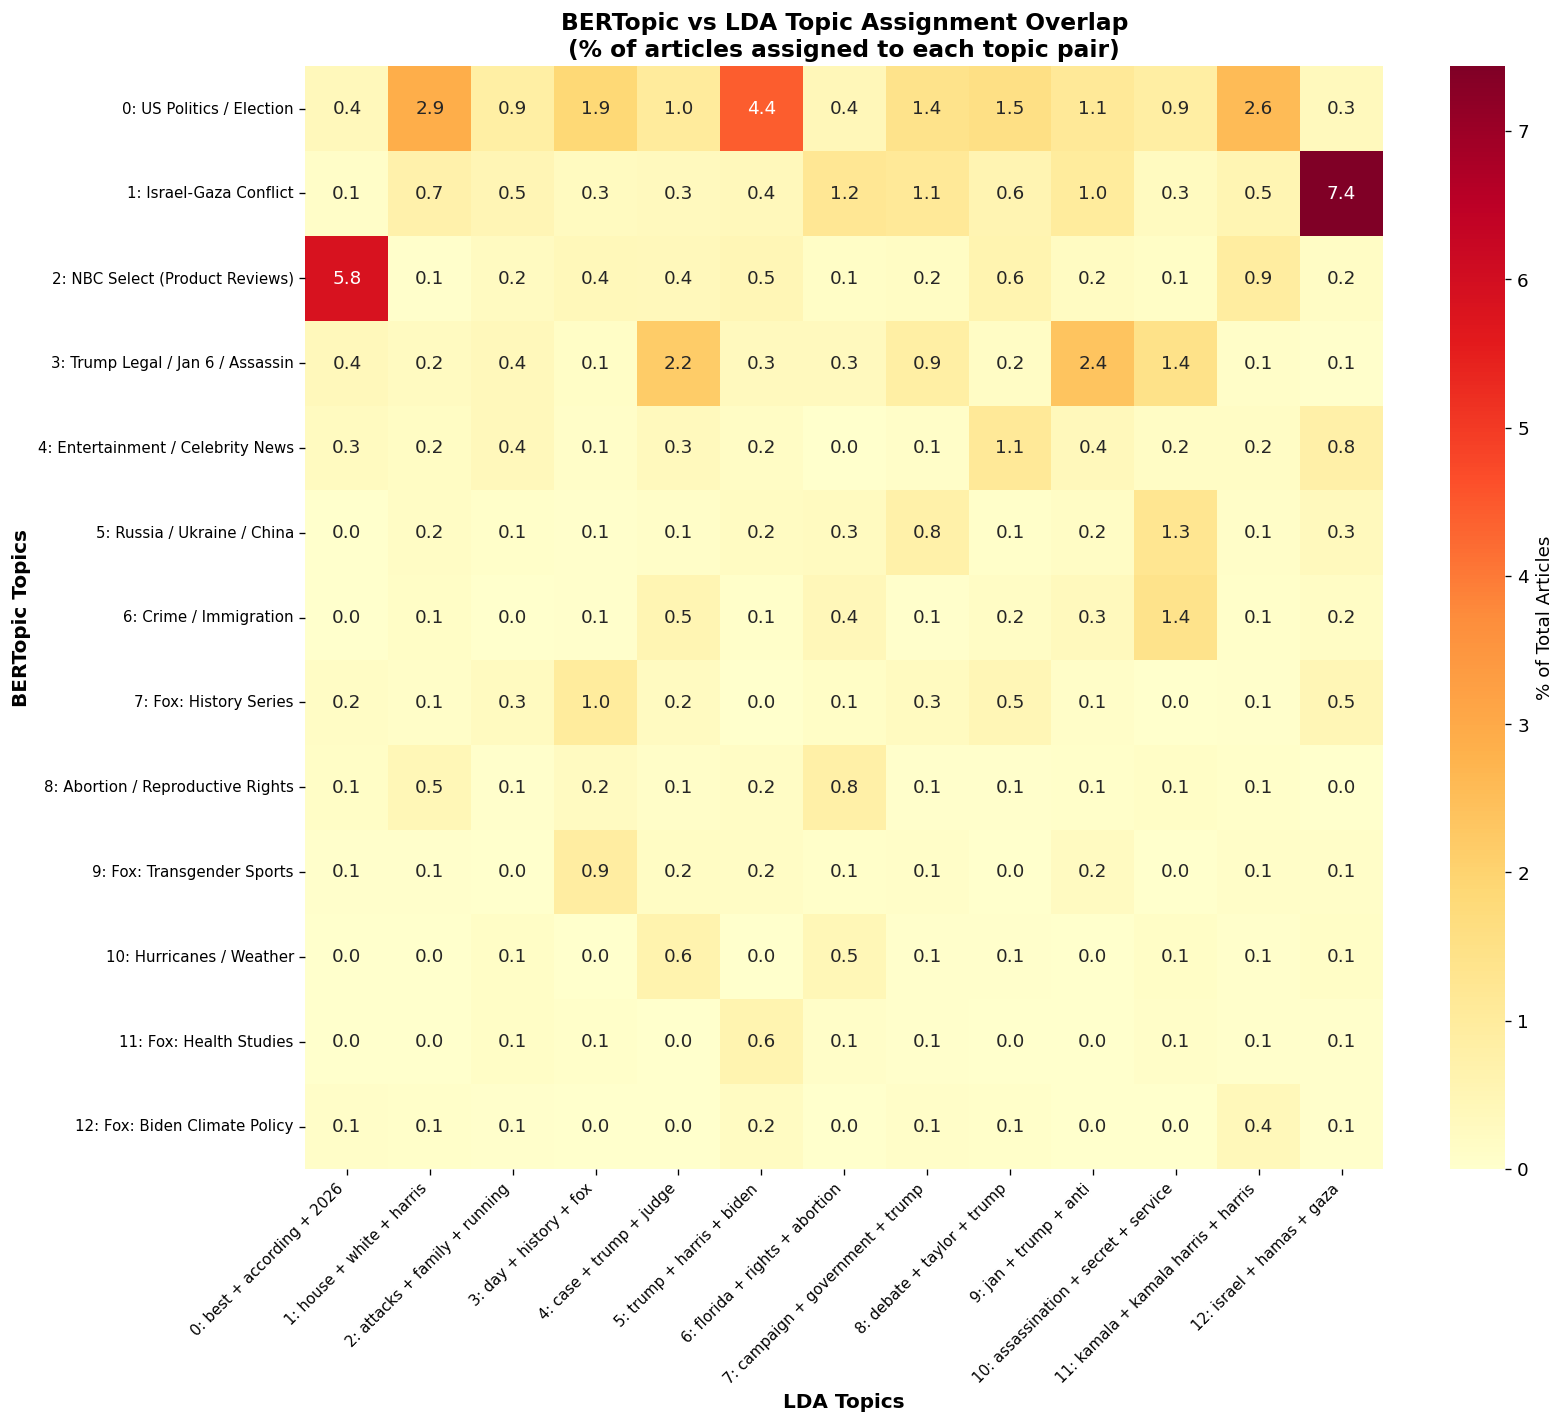

In [ ]:
topic_df['lda_topic_id'] = lda_assignments

headline_df = headline_df.merge(topic_df[['url', 'lda_topic_id']], on='url', how='left')

# Get aligned assignments
bertopic_assignments = headline_df['topic_id'].values
lda_assignments_aligned = headline_df['lda_topic_id'].values
total_articles = len(headline_df)

print(f'Comparing {total_articles} articles (those with title AND datetime)')

# Create overlap matrix: % of articles in each (BERTopic, LDA) pair
overlap_matrix = np.zeros((13, 13))

for bert_topic in range(13):
    for lda_topic in range(13):
        # Count articles in both topics
        both = ((bertopic_assignments == bert_topic) & (lda_assignments_aligned == lda_topic)).sum()
        # Calculate as % of total articles
        overlap_matrix[bert_topic, lda_topic] = (both / total_articles) * 100

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Get topic names for labels
bert_labels = [f'{i}: {topic_labels[i][:30]}' for i in range(13)]
lda_top_words = []
for i in range(13):
    top_words_idx = lda_model.components_[i].argsort()[-3:][::-1]
    top_words = [vectorizer.get_feature_names_out()[j] for j in top_words_idx]
    lda_top_words.append(f'{i}: {" + ".join(top_words)}')

sns.heatmap(overlap_matrix, 
            xticklabels=lda_top_words, 
            yticklabels=bert_labels,
            cmap='YlOrRd', 
            annot=True, 
            fmt='.1f',
            cbar_kws={'label': '% of Total Articles'},
            ax=ax)

ax.set_title('BERTopic vs LDA Topic Assignment Overlap\n(% of articles assigned to each topic pair)', 
             fontweight='bold', fontsize=14)
ax.set_xlabel('LDA Topics', fontweight='bold', fontsize=12)
ax.set_ylabel('BERTopic Topics', fontweight='bold', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# 4. Clustering from the embeddings

/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/utils/extmath

PC1 variance explained: 0.05103958770632744
PC2 variance explained: 0.038606196641922


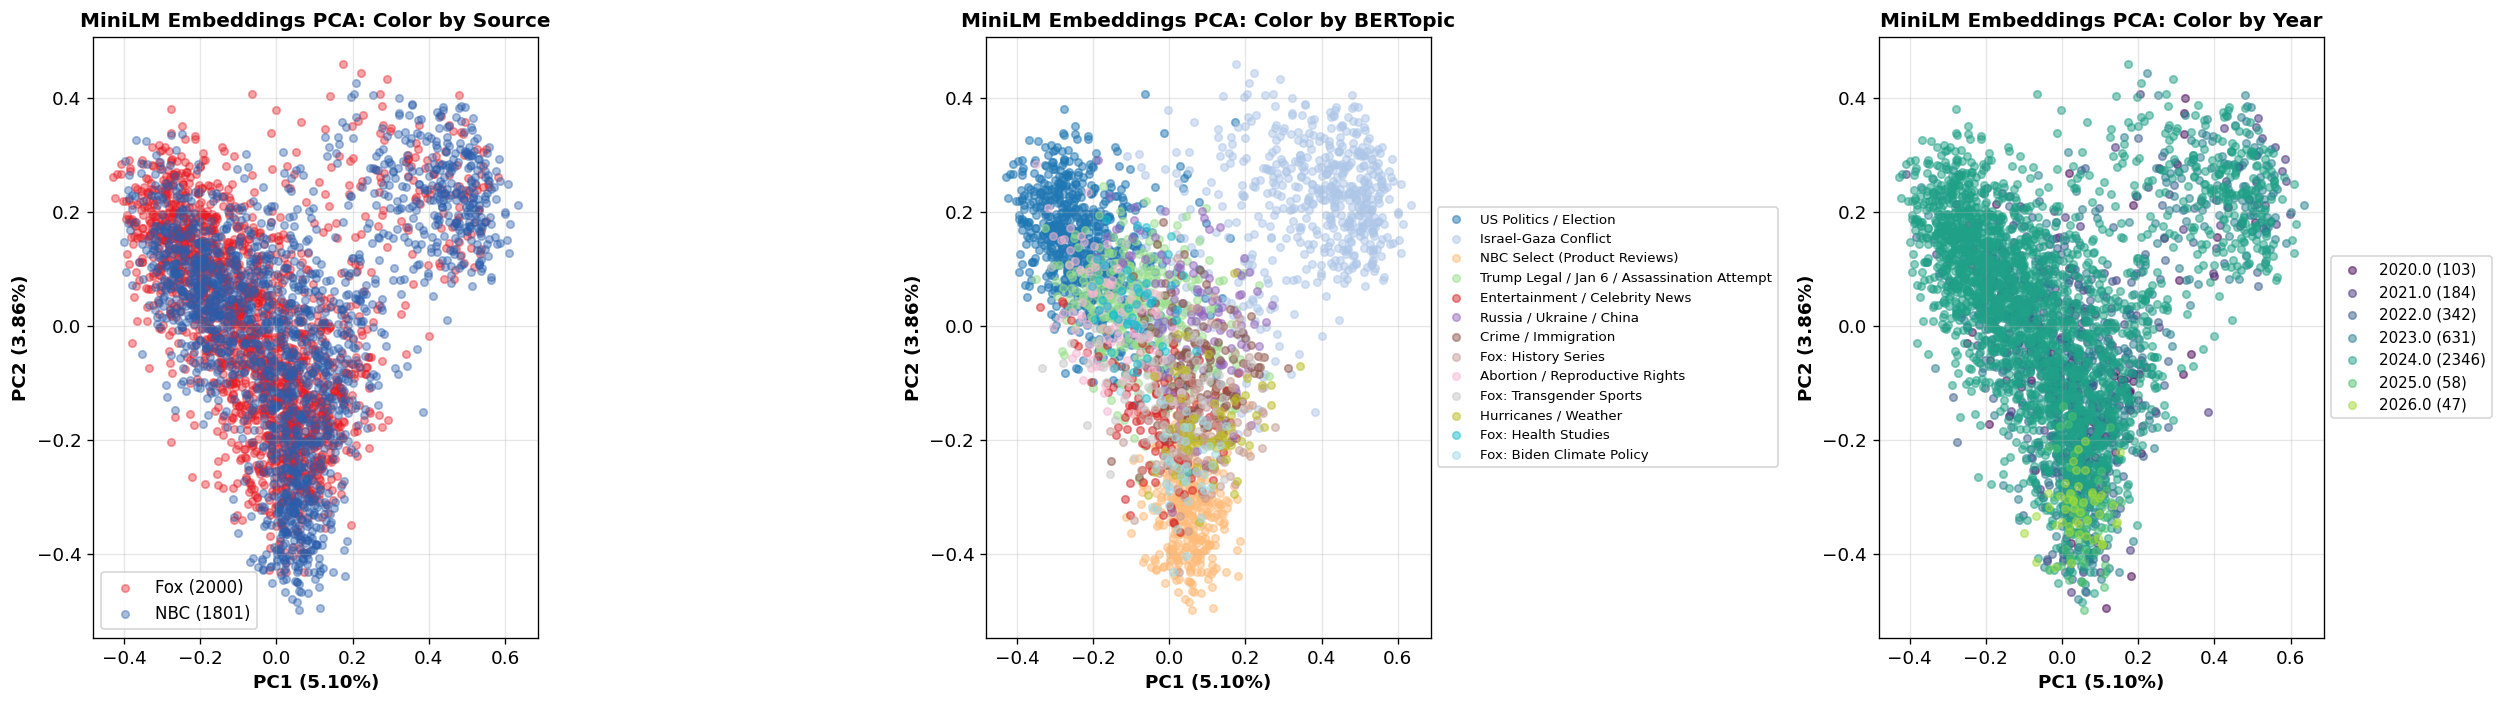

In [ ]:
# PCA for viz
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

print(f'PC1 variance explained: {pca.explained_variance_ratio_[0]}')
print(f'PC2 variance explained: {pca.explained_variance_ratio_[1]}')

topic_df['year'] = topic_df['datetime_posted'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# source
ax = axes[0]
fox_mask = topic_df['is_fox'] == 1
nbc_mask = topic_df['is_fox'] == 0

ax.scatter(embeddings_2d[fox_mask, 0], embeddings_2d[fox_mask, 1], 
           color=FOX_COLOR, alpha=0.4, s=20, label=f'Fox ({fox_mask.sum()})')
ax.scatter(embeddings_2d[nbc_mask, 0], embeddings_2d[nbc_mask, 1], 
           color=NBC_COLOR, alpha=0.4, s=20, label=f'NBC ({nbc_mask.sum()})')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontweight='bold')
ax.set_title('MiniLM Embeddings PCA: Color by Source', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# topic
ax = axes[1]
topic_colors = plt.cm.tab20(np.linspace(0, 1, 13))
topic_color_map = {i: topic_colors[i] for i in range(13)}

for topic_id in range(13):
    mask = topic_df['topic_id'] == topic_id
    if mask.sum() > 0:
        ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                   color=topic_color_map[topic_id], alpha=0.5, s=20, 
                   label=topic_labels[topic_id])

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontweight='bold')
ax.set_title('MiniLM Embeddings PCA: Color by BERTopic', fontweight='bold', fontsize=12)
ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(alpha=0.3)

# year
ax = axes[2]
years = sorted(topic_df['year'].unique())
year_colors = plt.cm.viridis(np.linspace(0, 1, len(years)))
year_color_map = {year: year_colors[i] for i, year in enumerate(years)}

for year in years:
    mask = topic_df['year'] == year
    if mask.sum() > 0:
        ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                   color=year_color_map[year], alpha=0.5, s=20, 
                   label=f'{year} ({mask.sum()})')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontweight='bold')
ax.set_title('MiniLM Embeddings PCA: Color by Year', fontweight='bold', fontsize=12)
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/parthas/Documents/cis5190_final/.venv/lib/python3.9/site-packages/sklearn/cluster/_k

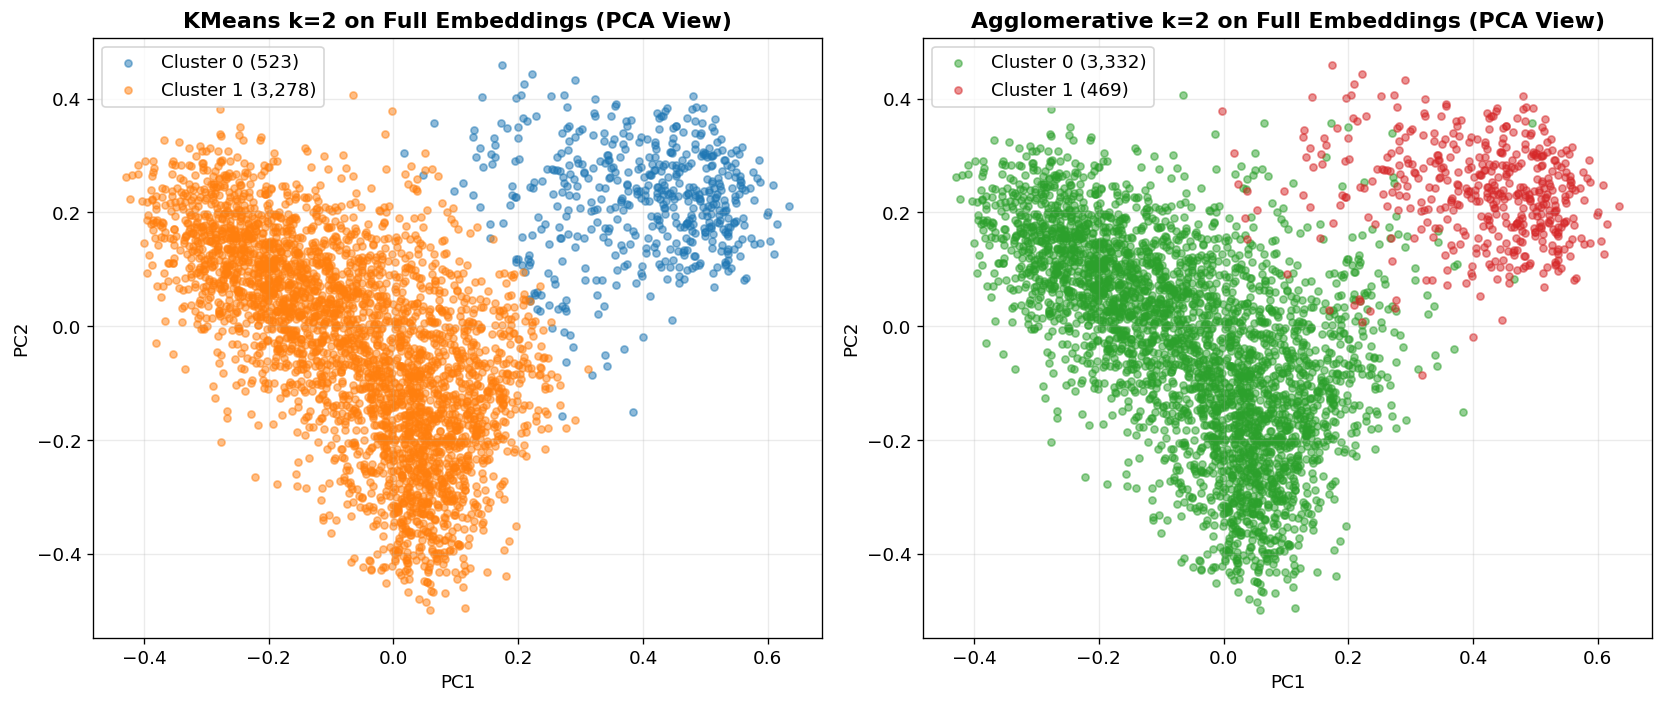

In [ ]:
# try some clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(embeddings)

agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for lbl, color in zip([0, 1], ['#1f77b4', '#ff7f0e']):
    mask = kmeans_labels == lbl
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], s=18, alpha=0.5, color=color, label=f'Cluster {lbl} ({mask.sum():,})')
ax.set_title('KMeans k=2 on Full Embeddings (PCA View)', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.grid(alpha=0.25)

ax = axes[1]
for lbl, color in zip([0, 1], ['#2ca02c', '#d62728']):
    mask = agg_labels == lbl
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], s=18, alpha=0.5, color=color, label=f'Cluster {lbl} ({mask.sum():,})')
ax.set_title('Agglomerative k=2 on Full Embeddings (PCA View)', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()